Random forest model for predicting abnormal CMP lab results

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    f1_score,
    confusion_matrix,
    classification_report
)

1.) Load dataset

In [29]:
df = pd.read_csv("data/processed/final_model_df.csv", parse_dates=["charttime"])

# Drop duplicates and empty cells as a safety condition, assert subject_id and target_abnormal are integers
df = df.dropna(subset=["subject_id", "target_abnormal"]).drop_duplicates().copy()
df["subject_id"] = df["subject_id"].astype(int)
df["target_abnormal"] = df["target_abnormal"].astype(int)

print("Dataset shape:", df.shape)
print("Target distribution:")
print(df["target_abnormal"].value_counts(normalize=True))

Dataset shape: (2914207, 55)
Target distribution:
target_abnormal
1    0.889656
0    0.110344
Name: proportion, dtype: float64


2.) Define features

In [30]:
# Should not be used for training
exclude_cols = {
    "subject_id",
    "hadm_id",
    "target_abnormal",
    "charttime",
    "prev_cmp_time",
    "chartdate",
    "admittime",
}

# Selected numeric feature groups
numeric_features = [
    "age",
    "length_of_stay_hours",
    "hours_since_last_cmp",
    "prior_abnormal_cmp_count",
    "abnormal_last_5_events",
    "bmi",
    "sbp",
    "dbp"
]

# Automatically detected prior lab value, lab value change, and diagnosis feature groups
prior_cols = [
    c for c in df.columns
    if c.startswith("prev_") and c not in exclude_cols and "time" not in c.lower() and "date" not in c.lower()
]

delta_cols = [
    c for c in df.columns
    if c.startswith("delta_") and c not in exclude_cols and "time" not in c.lower() and "date" not in c.lower()
]

diag_cols = [
    c for c in df.columns
    if c.startswith("dx_")
]

numeric_features = numeric_features + prior_cols + delta_cols + diag_cols

numeric_features = [c for c in numeric_features if c in df.columns and c not in exclude_cols]

# Selected categorical features
categorical_features = [
    "sex",
    "admission_type",
]

# All features
feature_cols = numeric_features + categorical_features

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))
print("Number of diagnosis features:", len(diag_cols))

Number of numeric features: 47
Number of categorical features: 2
Number of diagnosis features: 11


3.) Split dataset by patient

In [31]:
train_ratio = 0.70
test_ratio = 0.15
val_ratio = 0.15

# Create smaller dataframe using feature columns, patient ID, and coded abnormal flag
model_df = df[["subject_id"] + feature_cols + ["target_abnormal"]].copy()

# Splits to training and temporary groups by patient ID
gss1 = GroupShuffleSplit(n_splits=1, test_size=test_ratio + val_ratio, random_state=0)
train_idx, temp_idx = next(gss1.split(model_df, groups=model_df["subject_id"]))

train_df = model_df.iloc[train_idx].copy()
temp_df = model_df.iloc[temp_idx].copy()

# Splits temporary into test and validation by patient ID
gss2 = GroupShuffleSplit(n_splits=1, test_size=test_ratio / (test_ratio + val_ratio), random_state=0)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["subject_id"]))

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

total_rows = train_df.shape[0] + val_df.shape[0] + test_df.shape[0]

print("Train shape (" + f"{train_df.shape[0] / total_rows:.2%}" + "):", train_df.shape)
print("Validation shape (" + f"{val_df.shape[0] / total_rows:.2%}" + "):", val_df.shape)
print("Test shape (" + f"{test_df.shape[0] / total_rows:.2%}" + "):", test_df.shape)

Train shape (69.77%): (2033350, 51)
Validation shape (15.04%): (438153, 51)
Test shape (15.19%): (442704, 51)


In [32]:
target_col = "target_abnormal"

# Separate classes
train_majority = train_df[train_df[target_col] == 1]
train_minority = train_df[train_df[target_col] == 0]

# Downsample class 1 to match class 0
train_majority_downsampled = train_majority.sample(
    n=len(train_minority),
    random_state=0
)

# Combine back
train_df_balanced = pd.concat([train_majority_downsampled, train_minority])

# Shuffle
train_df_balanced = train_df_balanced.sample(frac=1, random_state=0).reset_index(drop=True)

In [33]:
# Training set
X_train = train_df_balanced[feature_cols]
y_train = train_df_balanced[target_col]

# Validation set
X_val = val_df[feature_cols]
y_val = val_df["target_abnormal"]

# Testing set
X_test = test_df[feature_cols]
y_test = test_df["target_abnormal"]

4.) Build pipeline

In [34]:
# Fill in missing values with median
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Fill in missing categories with most frequent, convert categories to one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(
         n_estimators=300,
        max_depth=12,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight={0: 3, 1: 1},
        random_state=0,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
print("Random forest training complete.")

Random forest training complete.


5.) Tune classification threshold

In [35]:
def compute_metrics_at_threshold(y_true, y_prob, threshold):
    """Converts model output probability to class based on threshold

    Args:
        y_true (int): Label from dataset
        y_prob (float): Predicted probability
        threshold (float): Cutoff point for probabilities to class predictions

    Returns:
        Computed metrics at that threshold
    """
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)
    f1 = f1_score(y_true, y_pred)

    return {
        "threshold": threshold,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "ppv": ppv,
        "npv": npv,
        "f1": f1
    }

In [36]:
# Compute AUROC for validation set
val_probs = rf_model.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, val_probs)

# Evaluate all thresholds in 0.05 increments from 0.10 to 0.90
thresholds = np.arange(0.10, 0.91, 0.05)
val_results = [compute_metrics_at_threshold(y_val, val_probs, t) for t in thresholds]
val_results_df = pd.DataFrame(val_results)

# Target threshold values based on sensitivity as most improtant metric
target_sensitivity = 0.8
eligible = val_results_df[val_results_df["sensitivity"] >= target_sensitivity].copy()

# Rank thresholds that exceed the target sensitivity by sensitivity and f1 score
chosen_row = eligible.sort_values(by=["specificity", "f1"], ascending=False).iloc[0]
chosen_threshold = float(chosen_row["threshold"])

print(f"Validation AUROC: {val_auc:.4f}")
print("Chosen threshold:", chosen_threshold)
display(val_results_df)

Validation AUROC: 0.9107
Chosen threshold: 0.20000000000000004


,threshold,sensitivity,specificity,ppv,npv,f1
0,0.10,0.968941,0.363190,0.925090,0.590288,0.946507
1,0.15,0.896057,0.655556,0.954780,0.437277,0.924487
2,0.20,0.837694,0.806733,0.972360,0.379810,0.900017
3,0.25,0.789915,0.890311,0.983179,0.343033,0.876014
4,0.30,0.747458,0.938019,0.989886,0.313960,0.851758
5,0.35,0.708836,0.964651,0.993893,0.289876,0.827504
6,0.40,0.671937,0.978840,0.996135,0.268804,0.802531
7,0.45,0.636274,0.987849,0.997653,0.250727,0.777000
8,0.50,0.598521,0.993196,0.998601,0.233600,0.748451
9,0.55,0.558781,0.996192,0.999161,0.217641,0.716731


6.) Evaluate on test set

In [37]:
test_probs = rf_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probs)

test_metrics = compute_metrics_at_threshold(y_test, test_probs, chosen_threshold)
test_preds = (test_probs >= chosen_threshold).astype(int)

print(f"Test AUROC: {test_auc:.4f}")
print("Test metrics:")
for k, v in test_metrics.items():
    if k != "threshold":
        print(f"{k}: {v:.4f}")

print("\nClassification report:")
print(classification_report(y_test, test_preds, digits=4))

Test AUROC: 0.9109
Test metrics:
sensitivity: 0.8387
specificity: 0.8051
ppv: 0.9720
npv: 0.3823
f1: 0.9004

Classification report:
              precision    recall  f1-score   support

           0     0.3823    0.8051    0.5184     48847
           1     0.9720    0.8387    0.9004    393857

    accuracy                         0.8350    442704
   macro avg     0.6771    0.8219    0.7094    442704
weighted avg     0.9069    0.8350    0.8583    442704



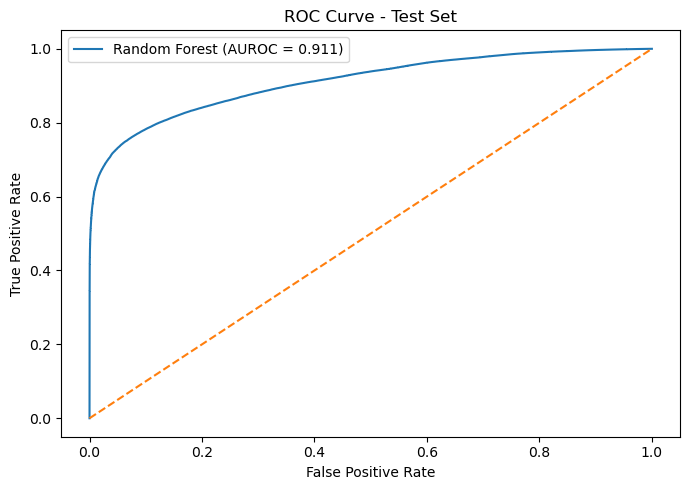

In [38]:
# Display ROC curve
fpr, tpr, _ = roc_curve(y_test, test_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUROC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.tight_layout()
plt.show()

7.) Feature analysis

In [39]:
rf_clf = rf_model.named_steps["clf"]
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_clf.feature_importances_
}).sort_values("importance", ascending=False)

print("Top feature importances:")
display(importance_df.head(20))

Top feature importances:


,feature,importance
31,num__delta_glucose,0.179472
4,num__abnormal_last_5_events,0.106798
21,num__prev_bun,0.088715
17,num__prev_glucose,0.081269
35,num__delta_bun,0.067603
16,num__prev_creatinine,0.053682
30,num__delta_creatinine,0.052698
28,num__delta_total_calcium,0.047546
26,num__delta_bicarbonate,0.046584
46,num__dx_other,0.027089


In [40]:
val_results_df.to_csv("data/processed/rf_validation_threshold_results.csv", index=False)
importance_df.to_csv("data/processed/rf_feature_importances.csv", index=False)

summary_df = pd.DataFrame([{
    "model": "random_forest",
    "threshold": chosen_threshold,
    "validation_auroc": val_auc,
    "test_auroc": test_auc,
    "test_sensitivity": test_metrics["sensitivity"],
    "test_specificity": test_metrics["specificity"],
    "test_ppv": test_metrics["ppv"],
    "test_npv": test_metrics["npv"],
    "test_f1": test_metrics["f1"]
}])

summary_df.to_csv("data/processed/rf_model_summary.csv", index=False)
summary_df

,model,threshold,validation_auroc,test_auroc,test_sensitivity,test_specificity,test_ppv,test_npv,test_f1
0,random_forest,0.2,0.910739,0.910857,0.838675,0.805085,0.971984,0.382307,0.900422
